# Fine-Tuning ProPicker on EMPIAR-10988

This notebook demonstrates how to fine-tune ProPicker for picking ribosomes in the EMPIAR-10988 dataset.

## Overview

We use a crop of size `128x128x128` voxels extracted from the center of the `TS_029` tomogram and corresponding ground truth annotations for fine-tuning. The crop contains 65 ribosomes which is less than 3% of the total number of ribosomes in the full `TS_029` tomogram.

For early stopping, we use a `128x128x128` center crop from `TS_030` and corresponding ground-truth annotations (66 ribosomes).

## Prerequisites

Before running this notebook, ensure you have:
1. Configured paths in `config.py` at project root
2. Downloaded the EMPIAR-10988 dataset
3. Downloaded the TomoTwin model checkpoint

In [ ]:
import sys
from pathlib import Path

# Add project root and experiments to path
PROJECT_ROOT = Path("../..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "experiments"))

# Import paths (file system locations)
from paths import (
    EMPIAR10988_BASE_DIR,
    TOMOTWIN_MODEL_FILE,
    PROPICKER_TOOLS_DIR,
    EXP2_RESULTS_DIR,
    EXP2_FINETUNING_DIR,
)

# Import config (experiment parameters and utilities)
from config import (
    setup_propicker_paths,
    RIBOSOME_NAME,
    RIBOSOME_PROMPT_SIZE,
    RIBOSOME_DIAMETER,
)

# Setup ProPicker imports
PROPICKER_DIR = setup_propicker_paths()

# Alias for compatibility with the rest of the notebook
PARTICLE_TYPE = RIBOSOME_NAME
EXP_RESULTS_DIR = EXP2_RESULTS_DIR
FINETUNING_DIR = EXP2_FINETUNING_DIR

# Create directories if they don't exist
EXP_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FINETUNING_DIR.mkdir(parents=True, exist_ok=True)

import torch
from matplotlib import pyplot as plt

from clustering_and_picking import get_cluster_centroids_df
from evaluation import evaluate_picks
from data.preparation_functions.prepare_empiar10988 import read_empiar10988_coords, empiar10988_ts_to_slice_of_interest
from inference.tomotwin import get_tomotwin_prompt_embeds_dict
from utils.mrctools import *

import warnings
warnings.filterwarnings("ignore")

print(f"ProPicker tools: {PROPICKER_DIR}")
print(f"EMPIAR10988 data: {EMPIAR10988_BASE_DIR}")
print(f"TomoTwin model: {TOMOTWIN_MODEL_FILE}")
print(f"Results dir: {EXP_RESULTS_DIR}")
print(f"\nRibosome parameters:")
print(f"  Particle type: {PARTICLE_TYPE}")
print(f"  Prompt size: {RIBOSOME_PROMPT_SIZE}×{RIBOSOME_PROMPT_SIZE}×{RIBOSOME_PROMPT_SIZE}")
print(f"  Diameter: {RIBOSOME_DIAMETER}")

## Setup: DeepETPicker Environment for Fine-Tuning

Fine-tuning ProPicker uses our `DeepETPicker_ProPicker` fork of [DeepETPicker](https://github.com/cbmi-group/DeepETPicker), which is integrated as a submodule in ProPicker.

To run the fine-tuning code, you need a separate conda environment:

```bash
cd tools/ProPicker/DeepETPicker_ProPicker
conda env create -f environment.yml
conda activate deepetpicker
```

## Step 1: Prompt Extraction and Embedding

For fine-tuning ProPicker, we first need to extract a prompt, which is used to condition the model and which we keep fixed during fine-tuning. We use the same prompt as for the clustering-based picking approach.

In [ ]:
ts_id = "TS_030"

tomo_file = f"{EMPIAR10988_BASE_DIR}/tomograms/{ts_id}.rec"
ribo_coord_file = f"{EMPIAR10988_BASE_DIR}/particle_lists/{ts_id}_cyto_ribosomes.csv"

# Tomograms contain large empty regions, so we only consider the interesting part
slice_of_interest = empiar10988_ts_to_slice_of_interest[ts_id]
tomo = -1 * load_mrc_data(tomo_file).float()
tomo = tomo[slice_of_interest].clone()

coords = read_empiar10988_coords(ribo_coord_file)
coords.Z -= slice_of_interest.start

# Extract all ribosomes as subtomos of shape (37, 37, 37)
# This shape is required for the TomoTwin prompt encoder
all_ribo_subtomos = []
for coord in coords[["X", "Y", "Z"]].values.astype(int):
    x, y, z = coord
    subtomo = tomo[
        z-18:z+19,
        y-18:y+19,
        x-18:x+19
    ]
    # Skip ribosomes at the edge of the tomogram
    if not subtomo.shape == (37, 37, 37):
        continue
    all_ribo_subtomos.append(subtomo)
    
# Choose any of the ribo subtomos as prompt
prompt = all_ribo_subtomos[300]
prompt_subtomos_dict = {"cyto_ribosome": prompt}

print(f"Extracted {len(all_ribo_subtomos)} valid subtomograms")
print(f"Prompt shape: {prompt.shape}")

/home/carlos-hg/Dev/ProPicker/utils/mrctools.py:8: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /opt/conda/conda-bld/pytorch_1720538456841/work/torch/csrc/utils/tensor_numpy.cpp:206.)
  data = torch.from_numpy(mrc.data)


We embed the prompt using tomotwin and save the embedding to disk, as we need it for fine-tuning.

In [ ]:
prompt_file = EXP_RESULTS_DIR / "fixed_prompts_empiar10988.json"

prompt_embeds_dict = get_tomotwin_prompt_embeds_dict(
    prompt_subtomos_dict=prompt_subtomos_dict, 
    tomotwin_model_file=str(TOMOTWIN_MODEL_FILE), 
    device="cuda:0", 
    batch_size=1, 
    out_file=str(prompt_file)
)

print(f"Prompt embeddings saved to: {prompt_file}")

/home/carlos-hg/Dev/ProPicker/inference/tomotwin.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(weightspth, map_location=device)


Model config:
{'identifier': 'SiameseNet', 'network_config': {'output_channels': 32, 'dropout': 0.2, 'repeat_layers': 0, 'norm_name': 'GroupNorm', 'norm_kwargs': {'num_groups': 64, 'num_channels': 1024}, 'gem_pooling_p': 0}, 'train_config': {'loss': 'TripletLoss', 'tl_margin': 0.539, 'miner': True, 'miner_margin': 0.734, 'learning_rate': 5.945e-05, 'optimizer': 'Adam', 'weight_decay': 0, 'batchsize': 35, 'patience': 50, 'aug_train_shift_distance': 2}, 'distance': 'COSINE'}
Successfully loaded model weights


Passing subtomos through TomoTwin: 100%|████████████████████████| 1/1 [00:00<00:00,  7.50it/s]


## Step 2: Fine-Tuning

Fine-tuning code is available in `scripts/fine_tuning.py`. Review the hyperparameters in the script, then run it in the `deepetpicker` environment:

```bash
conda activate deepetpicker
python scripts/fine_tuning.py
```

With the default settings, the script fine-tunes ProPicker on a crop of size `256x256x256` voxels extracted from the center of `TS_029`. A center crop of the same size from `TS_030` is used as validation set.

Running the fine-tuning script will create a directory `results/exp2_empiar10988_finetuning/fine_tuning/`, which contains all outputs produced during training. You can monitor the fine-tuning using TensorBoard:

```bash
tensorboard --logdir results/exp2_empiar10988_finetuning/fine_tuning/runs
```

## Step 3: Inference with the Fine-Tuned Model

Inference with the fine-tuned model is handled in `scripts/inference.py`, which must also be run in the `deepetpicker` environment:

```bash
python scripts/inference.py --checkpoint <path_to_best_checkpoint>
```

**Important:** Before running the script, adjust the path to the model checkpoint.

After inference, the `results/exp2_empiar10988_finetuning/inference/` directory will contain the full 3D segmentation masks. Let's visualize the results:

/tmp/ipykernel_9630/510480128.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pred_locmap = torch.load("./fine_tuning_empiar10988/crop_delta=64/runs/train/train_ProPicke

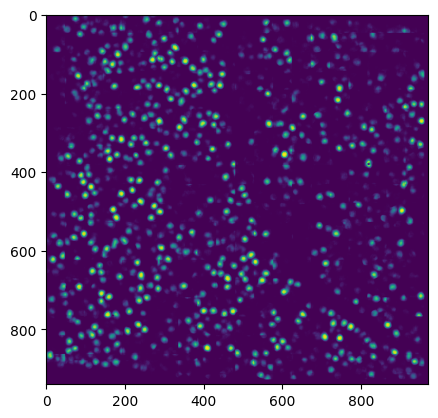

In [ ]:
# Load segmentation output (FINETUNING_DIR ya importado desde config)
FINETUNING_RUN_DIR = FINETUNING_DIR / "runs" / "train"

# Find the latest run directory
run_dirs = list(FINETUNING_RUN_DIR.glob("train_ProPicker_*"))
if run_dirs:
    latest_run = sorted(run_dirs)[-1]
    segmentation_dir = latest_run / "version_0" / "full_segmentation_output"
    print(f"Loading from: {segmentation_dir}")
else:
    # Fallback to manual path
    segmentation_dir = FINETUNING_RUN_DIR
    print(f"No runs found. Set segmentation_dir manually.")

# Load prediction for a test tomogram
test_ts_id = "TS_043"
pred_file = segmentation_dir / f"{test_ts_id}.pt"

if pred_file.exists():
    pred_locmap = torch.load(pred_file)
    plt.figure(figsize=(10, 8))
    plt.imshow(pred_locmap[50], cmap='viridis')
    plt.colorbar(label='Prediction score')
    plt.title(f'Segmentation output - {test_ts_id} (z=50)')
    plt.show()
else:
    print(f"Prediction file not found: {pred_file}")
    print("Run the fine-tuning and inference scripts first.")

In [ ]:
# Binarization
# After fine-tuning the model is usually much more confident,
# so increase the binarization threshold to avoid overlapping particle clusters
binarization_thresh = 0.5
binary_locmap = pred_locmap > binarization_thresh

# Clustering
cluster_centroids = get_cluster_centroids_df(binary_locmap)

# Size-based filtering using RIBOSOME_DIAMETER from config
ball_volume = 4/3 * torch.pi * (RIBOSOME_DIAMETER/2)**3  
min_cluster_size = 0.1 * ball_volume  
max_cluster_size = 1.2 * ball_volume 

cluster_centroids_filt = cluster_centroids[
    (min_cluster_size <= cluster_centroids["size"]) & (cluster_centroids["size"] <= max_cluster_size)
]

print(f"Number of clusters after filtering: {len(cluster_centroids_filt)}")
print(cluster_centroids_filt.head(5))

Number of clusters: 1815
       X      Y     Z  size
0  627.0   60.0   8.0  2160
1  768.0   69.0  10.0  2307
2  732.0   83.0   5.0  1676
3  714.0  147.0   6.0  2888
4  659.0  156.0   6.0  1908


In [ ]:
# Evaluate predictions against ground truth
ts_id = "TS_043"

# Load original tomogram and crop to slice of interest
tomo_file = f"{EMPIAR10988_BASE_DIR}/tomograms/{ts_id}.rec"
slice_of_interest = empiar10988_ts_to_slice_of_interest[ts_id]

tomo = -1 * load_mrc_data(tomo_file).float()
tomo = tomo[slice_of_interest].clone()
print(f"Tomogram loaded: {tomo.shape}")

# Load ground truth coordinates
ribo_coord_file = f"{EMPIAR10988_BASE_DIR}/particle_lists/{ts_id}_cyto_ribosomes.csv"
coords = read_empiar10988_coords(ribo_coord_file)
coords.Z -= slice_of_interest.start
print(f"Ground truth coordinates loaded: {len(coords)}")

# Prepare bounding boxes for evaluation using RIBOSOME_PROMPT_SIZE from config
bbox_size = RIBOSOME_PROMPT_SIZE

# Ground truth
coords["height"] = bbox_size
coords["width"] = bbox_size
coords["depth"] = bbox_size

# Predictions
cluster_centroids_filt["height"] = bbox_size
cluster_centroids_filt["width"] = bbox_size
cluster_centroids_filt["depth"] = bbox_size
cluster_centroids_filt["class"] = PARTICLE_TYPE

# Evaluate
results = evaluate_picks(
    pred_positions=cluster_centroids_filt,
    gt_positions=coords,
    iou_thresh=0.6,
)

print("\n" + "="*50)
print("EVALUATION RESULTS")
print("="*50)
print(results)

Tomograma cargado: torch.Size([153, 928, 960])
GT coords cargadas: 1815


/tmp/ipykernel_9630/2967366538.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_centroids_filt["height"] = bbox_size
/tmp/ipykernel_9630/2967366538.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_centroids_filt["width"]  = bbox_size
/tmp/ipykernel_9630/2967366538.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pan

{'cyto_ribosome': {'F1': 0.5714285714285714, 'Recall': 0.5752066115702479, 'Precision': 0.567699836867863, 'TruePositiveRate': 0.5752066115702479, 'TP': 1044, 'FP': 795, 'FN': 771}}


## Conclusion

Fine-tuning ProPicker significantly improves performance on the EMPIAR-10988 dataset. The fine-tuned model achieves higher precision and recall, with most improvements in recall.

### Key Takeaways

- Fine-tuning on less than 3% of the data (65 ribosomes) substantially improves detection
- The binarization threshold should be increased after fine-tuning due to higher model confidence
- Fine-tuning is especially effective for improving recall on challenging particles

### Next Steps

- Try different crop sizes and training parameters
- Evaluate on additional test tomograms
- Compare with zero-shot (prompt-based) picking results